# Customer Segmentation & Retention Marketing: RFM, Cohorts and CLV by Channel

> **Note:** personal practice project. The dataset is **simulated** (see `data/generate_data.py`)
> to mimic a home & lifestyle e-commerce store. Methodology is real; figures are not from a live client.

**Business question:** my two previous projects focused on *acquisition* (Google Ads, multi-platform budget).
This one asks the next question every marketing team faces: **once we pay to acquire a customer, who is worth keeping,
who is slipping away, and which acquisition channels actually bring customers that come back?**

**What this notebook does**
1. Cleans transactional data (duplicates, cancellations, refunds, missing channels)
2. Segments customers with **RFM** and validates the segments with **K-Means**
3. Measures concentration of revenue (Pareto)
4. Builds **cohort retention** and analyses **time to second purchase**
5. Calculates **12-month CLV and LTV:CAC by acquisition channel** (feeding back into budget decisions)
6. Sizes a **win-back campaign scenario** and exports **CRM-ready audiences**

## Key findings (simulated data, 5,837 customers, 24 months)

- **Repeat customers matter:** the 27.9% of customers who bought more than once generate **55% of revenue**.
- **Revenue is concentrated, but less than the "80/20" rule:** the top 20% of customers generate 48% of revenue; **Champions + Loyal are 10.6% of customers and 30% of revenue**.
- **The window to win the second order is early and mostly missed:** ~68% of customers with 6+ months of history never reordered, and only 7% reorder within 30 days (median time to 2nd order: 71 days).
- **Acquisition channels differ a lot in customer quality:** 12-month LTV:CAC is 3.1x for Google Search, 1.5x for Meta and 0.5x for Programmatic (Organic and Email/Referral look far better, but their CAC is an assumption).
- **Best win-back opportunity is "Needs Attention"** (1,046 customers, scenario ROI 3.9x), *before* they become Hibernating, where the same outreach does not pay back (0.8x).

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

DATA, IMG, REP = Path("../data"), Path("../images"), Path("../reports")
IMG.mkdir(exist_ok=True); REP.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook", rc={"axes.grid.axis": "y"})
PALETTE = {"primary": "#1f4e79", "accent": "#e07b39", "muted": "#9aa5b1", "good": "#2e8b57", "bad": "#c0392b"}
pd.options.display.float_format = "{:,.2f}".format

## 1. Data loading and cleaning

In [2]:
orders_raw = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"])
customers = pd.read_csv(DATA / "customers.csv")

log = {"Raw rows": len(orders_raw)}

orders = orders_raw.drop_duplicates()
log["Exact duplicate rows removed"] = len(orders_raw) - len(orders)

status = orders["status"].value_counts()
log["Cancelled orders removed"] = int(status.get("cancelled", 0))
log["Refunded orders removed"] = int(status.get("refunded", 0))
orders = orders[orders["status"] == "completed"].copy()

log["Customers with missing channel -> 'Unknown'"] = int(customers["acquisition_channel"].isna().sum())
customers["acquisition_channel"] = customers["acquisition_channel"].fillna("Unknown")

log["Clean completed orders"] = len(orders)
log["Customers with >=1 completed order"] = orders["customer_id"].nunique()
pd.Series(log, name="count").to_frame()

,count
Raw rows,9636
Exact duplicate rows removed,38
Cancelled orders removed,244
Refunded orders removed,129
Customers with missing channel -> 'Unknown',60
Clean completed orders,9225
Customers with >=1 completed order,5837


In [3]:
SNAPSHOT = orders["order_date"].max() + pd.Timedelta(days=1)   # "today" for recency
total_rev = orders["order_value"].sum()
n_cust = orders["customer_id"].nunique()
n_orders = len(orders)
per_cust = orders.groupby("customer_id")["order_id"].count()

kpis = pd.Series({
    "Period": f"{orders.order_date.min():%Y-%m-%d} -> {orders.order_date.max():%Y-%m-%d}",
    "Revenue": f"${total_rev:,.0f}",
    "Orders": f"{n_orders:,}",
    "Customers": f"{n_cust:,}",
    "Average order value (AOV)": f"${total_rev / n_orders:,.2f}",
    "Orders per customer": f"{n_orders / n_cust:.2f}",
    "Repeat purchase rate": f"{(per_cust > 1).mean():.1%}",
    "Revenue from repeat customers": f"{orders[orders.customer_id.isin(per_cust[per_cust > 1].index)].order_value.sum() / total_rev:.1%}",
}, name="KPI").to_frame()
kpis

,KPI
Period,2024-01-01 -> 2025-12-31
Revenue,"$570,837"
Orders,"9,225"
Customers,"5,837"
Average order value (AOV),$61.88
Orders per customer,1.58
Repeat purchase rate,27.9%
Revenue from repeat customers,55.0%


## 2. RFM segmentation

- **Recency (R):** days since last order (quintiles; 5 = most recent)
- **Frequency (F):** number of orders. ~70% of customers have a single order, so quintiles would be meaningless: I use fixed bins (1, 2, 3, 4-5, 6+) instead.
- **Monetary (M):** total revenue (quintiles; used to prioritise customers *within* a segment)

Segments are assigned with explicit, auditable rules on R and F, so a marketer can read and challenge them.

In [4]:
rfm = orders.groupby("customer_id").agg(
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
    frequency=("order_id", "nunique"),
    monetary=("order_value", "sum"),
)
rfm["recency"] = (SNAPSHOT - rfm["last_order"]).dt.days

rfm["R"] = pd.qcut(rfm["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["F"] = pd.cut(rfm["frequency"], bins=[0, 1, 2, 3, 5, np.inf], labels=[1, 2, 3, 4, 5]).astype(int)

def segment(r):
    R, F = r["R"], r["F"]
    if R >= 4 and F >= 4: return "Champions"
    if R >= 3 and F >= 3: return "Loyal"
    if R >= 4 and F == 2: return "Potential Loyalists"
    if R >= 4 and F == 1: return "New Customers"
    if R == 3 and F <= 2: return "Needs Attention"
    if R <= 2 and F >= 4: return "Can't Lose Them"
    if R <= 2 and F == 3: return "At Risk"
    return "Hibernating"

rfm["segment"] = rfm.apply(segment, axis=1)
rfm = rfm.join(customers.set_index("customer_id")["acquisition_channel"])
rfm.head()

,first_order,last_order,frequency,monetary,recency,R,M,F,segment,acquisition_channel
customer_id,,,,,,,,,,
C00001,2025-08-30,2025-08-30,1,18.12,124,4,1,1,New Customers,Meta Ads
C00002,2024-12-29,2024-12-29,1,91.45,368,2,4,1,Hibernating,Google Search
C00003,2025-10-25,2025-11-04,2,110.28,58,5,4,2,Potential Loyalists,Organic / SEO
C00004,2025-07-08,2025-07-08,1,78.55,177,3,3,1,Needs Attention,Google Search
C00005,2024-04-02,2024-04-02,1,35.06,639,1,1,1,Hibernating,Google Search


In [5]:
ORDER = ["Champions", "Loyal", "Potential Loyalists", "New Customers", "Needs Attention",
         "At Risk", "Can't Lose Them", "Hibernating"]

seg = rfm.groupby("segment").agg(
    customers=("R", "size"),
    revenue=("monetary", "sum"),
    avg_recency_days=("recency", "mean"),
    avg_orders=("frequency", "mean"),
    avg_revenue_per_customer=("monetary", "mean"),
).reindex(ORDER)
seg["pct_customers"] = seg["customers"] / seg["customers"].sum()
seg["pct_revenue"] = seg["revenue"] / seg["revenue"].sum()
seg["aov"] = seg["avg_revenue_per_customer"] / seg["avg_orders"]

view = seg[["customers", "pct_customers", "pct_revenue", "avg_recency_days", "avg_orders", "avg_revenue_per_customer"]].copy()
view["pct_customers"] = view["pct_customers"].map("{:.1%}".format)
view["pct_revenue"] = view["pct_revenue"].map("{:.1%}".format)
view

,customers,pct_customers,pct_revenue,avg_recency_days,avg_orders,avg_revenue_per_customer
segment,,,,,,
Champions,272,4.7%,17.3%,56.02,5.67,362.67
Loyal,347,5.9%,12.6%,124.85,3.38,206.80
Potential Loyalists,429,7.3%,9.4%,65.72,2.00,125.49
New Customers,1408,24.1%,14.9%,75.86,1.00,60.40
Needs Attention,1046,17.9%,13.2%,249.22,1.17,72.03
At Risk,85,1.5%,2.8%,437.14,3.00,186.90
Can't Lose Them,74,1.3%,3.8%,433.50,4.68,293.00
Hibernating,2176,37.3%,26.0%,504.42,1.11,68.31


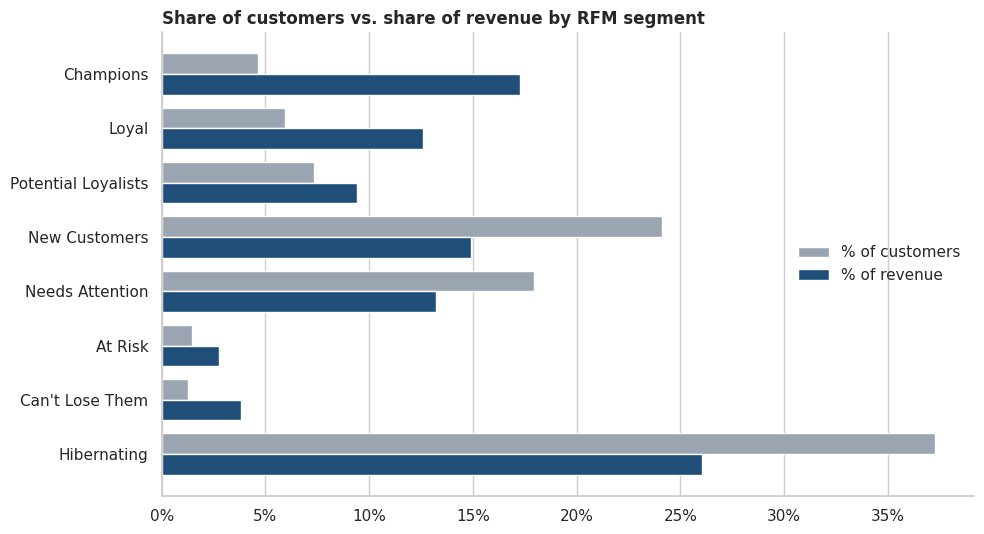

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(ORDER)); h = 0.38
ax.barh(y - h/2, seg["pct_customers"], h, label="% of customers", color=PALETTE["muted"])
ax.barh(y + h/2, seg["pct_revenue"], h, label="% of revenue", color=PALETTE["primary"])
ax.set_yticks(y); ax.set_yticklabels(ORDER); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_title("Share of customers vs. share of revenue by RFM segment", fontweight="bold", loc="left")
ax.legend(frameon=False, loc="center right")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
sns.despine(); plt.tight_layout()
plt.savefig(IMG / "01_segments_customers_vs_revenue.png", dpi=150); plt.show()

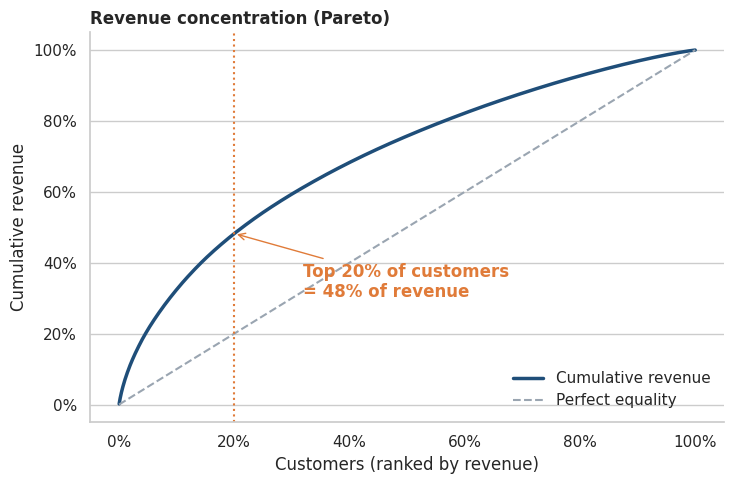

Top 10% of customers generate 32.5% of revenue; top 20% generate 48.2%.


In [7]:
# Pareto: how concentrated is revenue?
s = rfm["monetary"].sort_values(ascending=False).reset_index(drop=True)
cum_rev = s.cumsum() / s.sum()
cum_cust = (np.arange(1, len(s) + 1)) / len(s)
top20 = cum_rev[cum_cust >= 0.20].iloc[0]
top10 = cum_rev[cum_cust >= 0.10].iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(cum_cust, cum_rev, color=PALETTE["primary"], lw=2.5, label="Cumulative revenue")
ax.plot([0, 1], [0, 1], ls="--", color=PALETTE["muted"], label="Perfect equality")
ax.axvline(0.20, color=PALETTE["accent"], ls=":")
ax.annotate(f"Top 20% of customers\n= {top20:.0%} of revenue", (0.20, top20), xytext=(0.32, top20 - 0.18),
            arrowprops=dict(arrowstyle="->", color=PALETTE["accent"]), color=PALETTE["accent"], fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Customers (ranked by revenue)"); ax.set_ylabel("Cumulative revenue")
ax.set_title("Revenue concentration (Pareto)", fontweight="bold", loc="left"); ax.legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.savefig(IMG / "02_pareto_revenue.png", dpi=150); plt.show()
print(f"Top 10% of customers generate {top10:.1%} of revenue; top 20% generate {top20:.1%}.")

### Validating the segments with K-Means

Rule-based segments are easy to act on, but are they consistent with the structure in the data?
I cluster on log-scaled, standardised R, F and M and check silhouette scores. Silhouette is highest at very low *k*, 
so I restrict the search to *k* = 3-6 (the range a marketing team can realistically run distinct campaigns for).

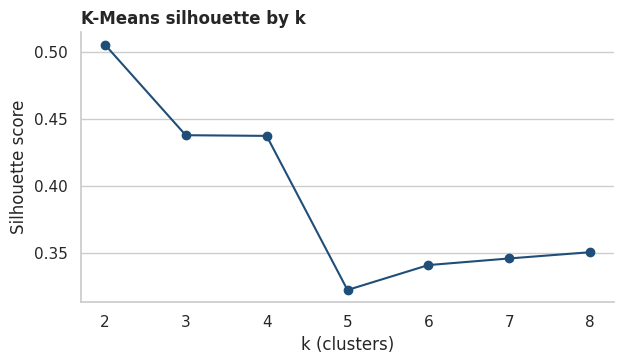

Chosen k = 3 (silhouette 0.44)


,customers,recency,frequency,monetary,dominant_rule_segment,share_in_dominant
cluster,,,,,,
0,3556,385.21,1.08,63.41,Hibernating,0.59
1,1109,180.89,3.58,237.53,Loyal,0.31
2,1172,43.27,1.20,69.92,New Customers,0.80


In [8]:
X = StandardScaler().fit_transform(np.log1p(rfm[["recency", "frequency", "monetary"]]))

sil = {}
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    sil[k] = silhouette_score(X, labels)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(list(sil), list(sil.values()), marker="o", color=PALETTE["primary"])
ax.set_xlabel("k (clusters)"); ax.set_ylabel("Silhouette score")
ax.set_title("K-Means silhouette by k", fontweight="bold", loc="left")
sns.despine(); plt.tight_layout(); plt.savefig(IMG / "03_kmeans_silhouette.png", dpi=150); plt.show()

best_k = max(range(3, 7), key=lambda k: sil[k])
rfm["cluster"] = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit_predict(X)
print(f"Chosen k = {best_k} (silhouette {sil[best_k]:.2f})")

profile = rfm.groupby("cluster").agg(customers=("R", "size"), recency=("recency", "mean"),
                                     frequency=("frequency", "mean"), monetary=("monetary", "mean"))
profile["dominant_rule_segment"] = rfm.groupby("cluster")["segment"].agg(lambda s: s.value_counts().index[0])
profile["share_in_dominant"] = rfm.groupby("cluster")["segment"].agg(lambda s: s.value_counts(normalize=True).iloc[0])
profile.round(2)

**Reading the result:** K-Means finds three broad groups: (0) a large base of lapsed one-time buyers, (1) a smaller group of repeat, higher-value customers
(about 19% of customers, 3.6 orders on average), and (2) recent, mostly first-time buyers. The eight rule-based segments split these into finer, actionable groups
(for example, separating Champions from At-Risk customers inside the repeat-buyer cluster), so the two views are consistent rather than identical.
I keep the rule-based segments for activation because each one maps to a different message.

## 3. Cohort retention

Customers are grouped by the month of their first purchase. Each cell shows the % of the cohort that placed an order
*in* month *k* after acquisition. Cells that have not yet had time to occur are left blank (not zero).

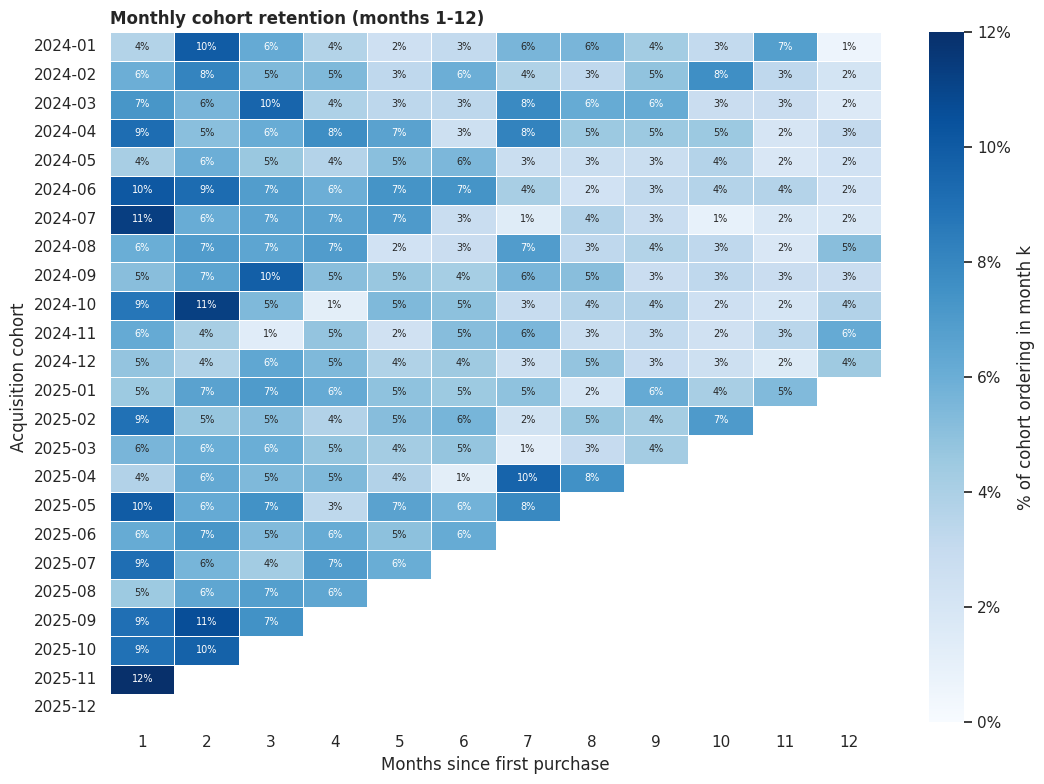

Average % of a cohort that orders in month 1 / 3 / 6 / 12: 7.2% / 6.2% / 4.5% / 3.0%


In [9]:
o = orders.copy()
o["order_month"] = o["order_date"].dt.to_period("M")
o["cohort"] = o.groupby("customer_id")["order_month"].transform("min")
o["period"] = (o["order_month"] - o["cohort"]).apply(lambda x: x.n)

cohort = o.groupby(["cohort", "period"])["customer_id"].nunique().unstack()
sizes = o.groupby("cohort")["customer_id"].nunique()
retention = cohort.divide(sizes, axis=0)

# mask periods that have not happened yet (instead of showing 0%)
last_month = o["order_month"].max()
for c in retention.index:
    max_p = (last_month - c).n
    retention.loc[c, retention.columns > max_p] = np.nan
retention = retention.fillna(np.nan)

plot_df = retention.loc[:, 1:12]
plot_df.index = plot_df.index.astype(str)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(plot_df, annot=True, fmt=".0%", annot_kws={"size": 7}, cmap="Blues", vmin=0, vmax=0.12,
            cbar_kws={"label": "% of cohort ordering in month k"}, linewidths=.4, linecolor="white", ax=ax)
ax.grid(False)
cbar = ax.collections[0].colorbar; cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("Acquisition cohort")
ax.set_title("Monthly cohort retention (months 1-12)", fontweight="bold", loc="left")
plt.tight_layout(); plt.savefig(IMG / "04_cohort_retention_heatmap.png", dpi=150); plt.show()

avg_ret = retention.loc[:, 1:12].mean()
print("Average % of a cohort that orders in month 1 / 3 / 6 / 12:",
      " / ".join(f"{avg_ret[m]:.1%}" for m in (1, 3, 6, 12)))

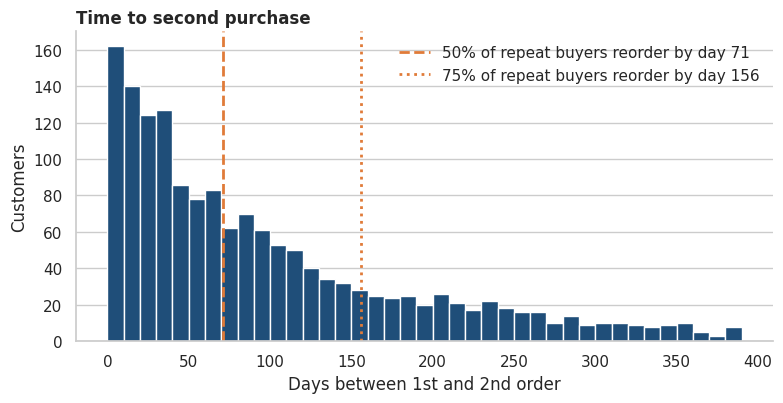

Median time to 2nd order: 71 days | one-time buyers (eligible base): 67.9%


,2nd order rate
within 14 days,3.7%
within 30 days,7.3%
within 60 days,12.3%
within 90 days,16.2%
within 180 days,23.8%


In [10]:
# Cumulative repeat rate: % of customers who have placed a 2nd order by day X (only customers with enough history)
o_sorted = orders.sort_values(["customer_id", "order_date"]).copy()
o_sorted["n"] = o_sorted.groupby("customer_id").cumcount() + 1
first_d = o_sorted[o_sorted.n == 1].set_index("customer_id")["order_date"]
second_d = o_sorted[o_sorted.n == 2].set_index("customer_id")["order_date"]
gap = (second_d - first_d.loc[second_d.index]).dt.days

eligible = first_d[first_d <= SNAPSHOT - pd.Timedelta(days=180)]        # at least 180 days of history
gap_el = gap[gap.index.isin(eligible.index)]
horizons = [14, 30, 60, 90, 180]
conv = pd.Series({f"within {d} days": (gap_el <= d).sum() / len(eligible) for d in horizons}, name="2nd order rate")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(gap, bins=range(0, 400, 10), color=PALETTE["primary"], edgecolor="white")
for p, ls in ((0.5, "--"), (0.75, ":")):
    ax.axvline(gap.quantile(p), color=PALETTE["accent"], ls=ls, lw=2,
               label=f"{int(p*100)}% of repeat buyers reorder by day {gap.quantile(p):.0f}")
ax.set_xlabel("Days between 1st and 2nd order"); ax.set_ylabel("Customers")
ax.set_title("Time to second purchase", fontweight="bold", loc="left"); ax.legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.savefig(IMG / "05_time_to_second_purchase.png", dpi=150); plt.show()

print(f"Median time to 2nd order: {gap.median():.0f} days | one-time buyers (eligible base): {1 - len(gap_el)/len(eligible):.1%}")
conv.to_frame().assign(**{"2nd order rate": lambda d: d["2nd order rate"].map("{:.1%}".format)})

## 4. 12-month CLV and LTV:CAC by acquisition channel

This connects retention back to acquisition spend. For customers acquired in 2024 (so every customer has a full 12 months
of history), I measure **actual revenue in the 12 months after the first order** and compare gross profit with CAC.

**Assumptions (explicit, change them in one place):**
- Gross margin: **45%**
- CAC for paid channels is taken from the simulated CPA in my [paid-media-budget-optimization](https://github.com/TomasVargas1911/paid-media-budget-optimization) project
  (Google Search $16.67, Meta $25.00, Programmatic = average of DV360 and The Trade Desk). Organic/SEO ($4) and Email/Referral ($8) are assumed allocations of content and incentive costs.

In [11]:
GROSS_MARGIN = 0.45
CAC = {"Google Search": 16.67, "Meta Ads": 25.00, "Programmatic": (50.00 + 55.17) / 2,
       "Organic / SEO": 4.00, "Email / Referral": 8.00}

fo = rfm["first_order"]
cohort_ids = fo[fo <= (SNAPSHOT - pd.Timedelta(days=366))].index          # >= 12 months of observation

od = orders[orders.customer_id.isin(cohort_ids)].merge(fo.rename("first_order"), left_on="customer_id", right_index=True)
od["days"] = (od["order_date"] - od["first_order"]).dt.days
od12 = od[od["days"] <= 365]

per_c = od12.groupby("customer_id").agg(rev12=("order_value", "sum"), orders12=("order_id", "nunique"))
first_val = od12[od12["days"] == 0].groupby("customer_id")["order_value"].first().rename("first_order_value")
per_c = per_c.join(first_val).join(customers.set_index("customer_id")["acquisition_channel"])
per_c = per_c[per_c.acquisition_channel != "Unknown"]

ch = per_c.groupby("acquisition_channel").agg(
    customers=("rev12", "size"),
    orders_12m=("orders12", "mean"),
    repeat_rate_12m=("orders12", lambda s: (s > 1).mean()),
    revenue_12m=("rev12", "mean"),
    first_order_value=("first_order_value", "mean"),
)
ch["gross_profit_12m"] = ch["revenue_12m"] * GROSS_MARGIN
ch["CAC"] = pd.Series(CAC)
ch["LTV:CAC"] = ch["gross_profit_12m"] / ch["CAC"]
ch["first_order_recovers_CAC"] = ch["first_order_value"] * GROSS_MARGIN / ch["CAC"]
ch = ch.sort_values("LTV:CAC", ascending=False)

fmt = ch.copy()
fmt["repeat_rate_12m"] = fmt["repeat_rate_12m"].map("{:.1%}".format)
fmt["first_order_recovers_CAC"] = fmt["first_order_recovers_CAC"].map("{:.0%}".format)
fmt["LTV:CAC"] = fmt["LTV:CAC"].map("{:.1f}x".format)
fmt

,customers,orders_12m,repeat_rate_12m,revenue_12m,first_order_value,gross_profit_12m,CAC,LTV:CAC,first_order_recovers_CAC
acquisition_channel,,,,,,,,,
Organic / SEO,551,1.87,36.7%,121.95,64.91,54.88,4.00,13.7x,730%
Email / Referral,266,2.17,47.0%,133.54,61.72,60.09,8.00,7.5x,347%
Google Search,773,1.72,35.2%,113.87,66.52,51.24,16.67,3.1x,180%
Meta Ads,631,1.44,26.9%,85.28,59.49,38.38,25.00,1.5x,107%
Programmatic,397,1.14,11.6%,58.91,52.07,26.51,52.59,0.5x,45%


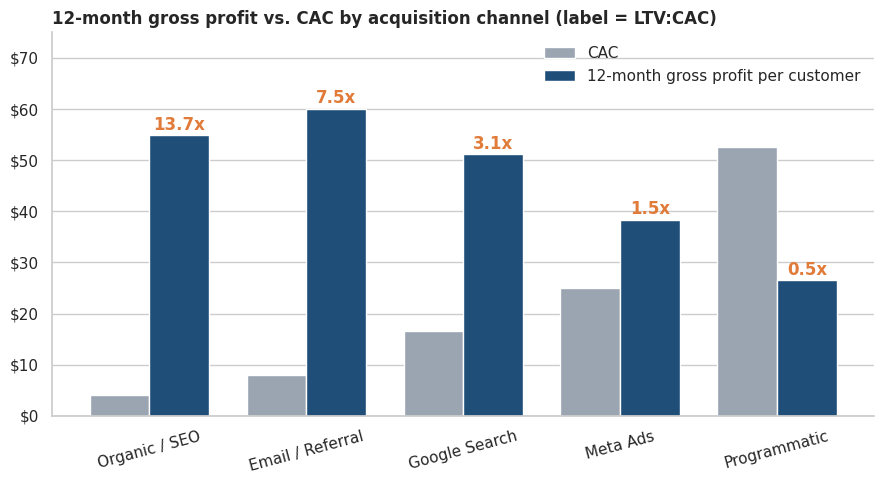

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ch)); w = 0.38
ax.bar(x - w/2, ch["CAC"], w, label="CAC", color=PALETTE["muted"])
ax.bar(x + w/2, ch["gross_profit_12m"], w, label="12-month gross profit per customer", color=PALETTE["primary"])
for i, (cac, gp, r) in enumerate(zip(ch["CAC"], ch["gross_profit_12m"], ch["LTV:CAC"])):
    ax.text(i + w/2, gp + 1, f"{r:.1f}x", ha="center", fontweight="bold", color=PALETTE["accent"])
ax.set_xticks(x); ax.set_xticklabels(ch.index, rotation=15)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("12-month gross profit vs. CAC by acquisition channel (label = LTV:CAC)", fontweight="bold", loc="left")
ax.set_ylim(0, 75); ax.legend(frameon=False, loc="upper right")
sns.despine(); plt.tight_layout()
plt.savefig(IMG / "06_ltv_vs_cac_by_channel.png", dpi=150); plt.show()

**Caveat on attribution:** channels like Programmatic are designed for awareness. With a last-touch view, their customers look
weak on LTV:CAC, but they may be assisting conversions credited to Search or Meta. This analysis should drive a *test* (e.g. geo or holdout lift test), not an automatic budget cut.

## 5. Win-back campaign scenario

Sizing the opportunity in the four segments that need re-engagement. **All rates below are illustrative assumptions**, 
the point is the framework: audience size x reactivation rate x order value x margin after discount, minus cost.
A real campaign must keep a **10% holdout group** to measure *incremental* reactivation (some of these customers would have returned anyway).

In [13]:
DISCOUNT = 0.15              # incentive on the win-back order
COST_PER_CONTACT = 0.30      # blended email/SMS/ads cost per customer reached over the whole flow
REACTIVATION = {"At Risk": 0.10, "Can't Lose Them": 0.15, "Needs Attention": 0.08, "Hibernating": 0.03}

rows = []
for s_name, rate in REACTIVATION.items():
    n = int(seg.loc[s_name, "customers"]); aov = seg.loc[s_name, "aov"]
    reactivated = n * rate
    revenue = reactivated * aov * (1 - DISCOUNT)
    gross_profit = revenue - reactivated * aov * (1 - GROSS_MARGIN)
    cost = n * COST_PER_CONTACT
    rows.append(dict(segment=s_name, audience=n, assumed_reactivation=rate, reactivated_customers=reactivated,
                     incremental_revenue=revenue, incremental_gross_profit=gross_profit, campaign_cost=cost,
                     net_profit=gross_profit - cost))
wb = pd.DataFrame(rows).set_index("segment")
wb.loc["TOTAL"] = wb.sum(numeric_only=True)
wb.loc["TOTAL", "assumed_reactivation"] = wb.loc["TOTAL", "reactivated_customers"] / wb.loc["TOTAL", "audience"]
wb["ROI on campaign cost"] = wb["net_profit"] / wb["campaign_cost"]

out = wb.copy()
out["assumed_reactivation"] = out["assumed_reactivation"].map("{:.1%}".format)
out["audience"] = out["audience"].map("{:,.0f}".format)
out["reactivated_customers"] = out["reactivated_customers"].map("{:,.0f}".format)
out["ROI on campaign cost"] = out["ROI on campaign cost"].map("{:.1f}x".format)
out

,audience,assumed_reactivation,reactivated_customers,incremental_revenue,incremental_gross_profit,campaign_cost,net_profit,ROI on campaign cost
segment,,,,,,,,
At Risk,85,10.0%,8,450.11,158.86,25.50,133.36,5.2x
Can't Lose Them,74,15.0%,11,591.24,208.67,22.20,186.47,8.4x
Needs Attention,"1,046",8.0%,84,"4,371.23","1,542.79",313.80,"1,228.99",3.9x
Hibernating,"2,176",3.0%,65,"3,415.14","1,205.34",652.80,552.54,0.8x
TOTAL,"3,381",5.0%,169,"8,827.71","3,115.66","1,014.30","2,101.36",2.1x


In [14]:
# Export CRM-ready audiences (e.g. for Klaviyo / Mailchimp / Google Ads Customer Match / Meta Custom Audiences)
audiences = (rfm.reset_index()
             [["customer_id", "segment", "R", "F", "M", "recency", "frequency", "monetary", "last_order", "acquisition_channel"]]
             .sort_values(["segment", "monetary"], ascending=[True, False]))
audiences.to_csv(REP / "crm_audiences.csv", index=False)
print(f"Saved {len(audiences):,} customers -> reports/crm_audiences.csv")

Saved 5,837 customers -> reports/crm_audiences.csv


## 6. Recommended actions

| Segment | Goal | Tactic | Channel | KPI to track |
|---|---|---|---|---|
| **Champions / Loyal** | Protect and grow | Early access, loyalty tier, referral programme (no discounts) | Email, SMS | Repeat rate, AOV, referrals |
| **Potential Loyalists / New** | Secure the 2nd order | Post-purchase flow timed to the median time-to-2nd-order, cross-sell | Email, retargeting | 2nd-order rate within 60 days |
| **Needs Attention** | Re-engage before they cool | Personalised reminder, social proof, light incentive | Email, Meta | Reactivation rate |
| **At Risk / Can't Lose** | Win back high-value customers | Personal outreach + stronger offer, feedback survey | Email, SMS, Customer Match | Incremental revenue vs holdout |
| **Hibernating** | Stop spending, one cheap last attempt | In the scenario, outreach at ~$0.30/contact returns 0.8x, so use an email-only sunset sequence (near-zero cost) and exclude them from paid audiences | Email only | Cost per reactivation |

**Feedback to acquisition:** shift budget *tests* toward the channels with the best LTV:CAC and build lookalike / similar audiences from
Champions (not from all purchasers).

## 7. Limitations and next steps
- Simulated data: the patterns are plausible but the numbers must not be read as benchmarks.
- 12-month CLV is observed, not predicted. A natural next step is a probabilistic model (BG/NBD + Gamma-Gamma) to project CLV for newer cohorts.
- Reactivation rates and margins are assumptions; replace with A/B test results.
- Next: run the same pipeline on a public real dataset (UCI Online Retail II) by mapping its columns to the `orders`/`customers` schema.